# Chart Expressions

Polars expression factories available in `mplchart.expressions`.
Expressions work natively with polars DataFrames — no pandas conversion needed.
Pass them directly to `chart.plot()` just like regular indicators.

In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume
from mplchart.expressions import (
    SMA, EMA, RMA, WMA, HMA, DEMA, TEMA,
    RSI, MACD, STOCH, ROC, MOM,
    TRANGE, ATR, BBANDS, DONCHIAN, KELTNER,
    MIDPRICE, TYPPRICE, WCLPRICE,
)

prices = sample_prices(backend="polars")

## Moving Averages

`SMA`, `EMA`, `RMA`, `WMA`, `HMA`, `DEMA`, `TEMA` — all accept an optional `src` expression.

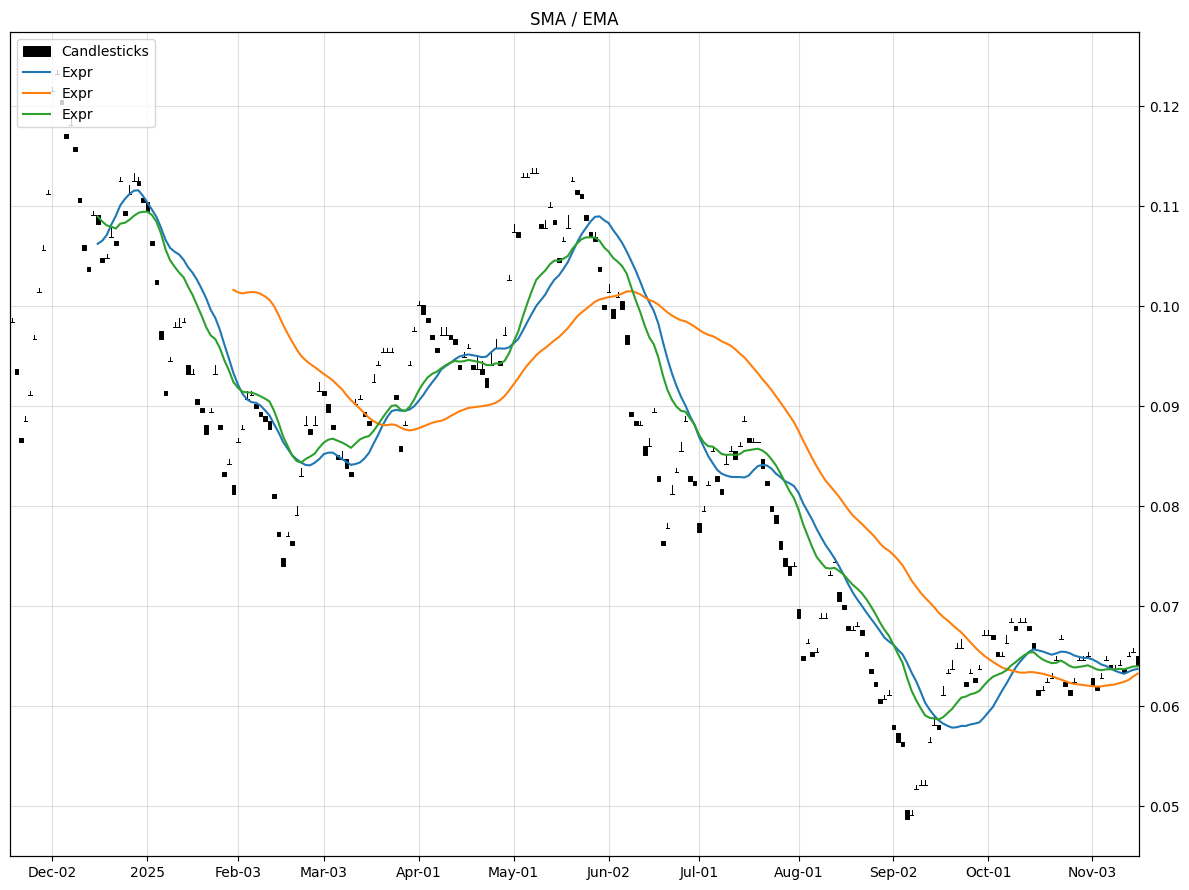

In [2]:
Chart(prices, title="SMA / EMA", max_bars=250).plot(
    Candlesticks(),
    SMA(20),
    SMA(50),
    EMA(20),
).show()


thread '<unnamed>' (1798622) panicked at crates/polars-compute/src/rolling/nulls/sum.rs:24:9:
weights not yet supported on array with null values
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


PanicException: weights not yet supported on array with null values

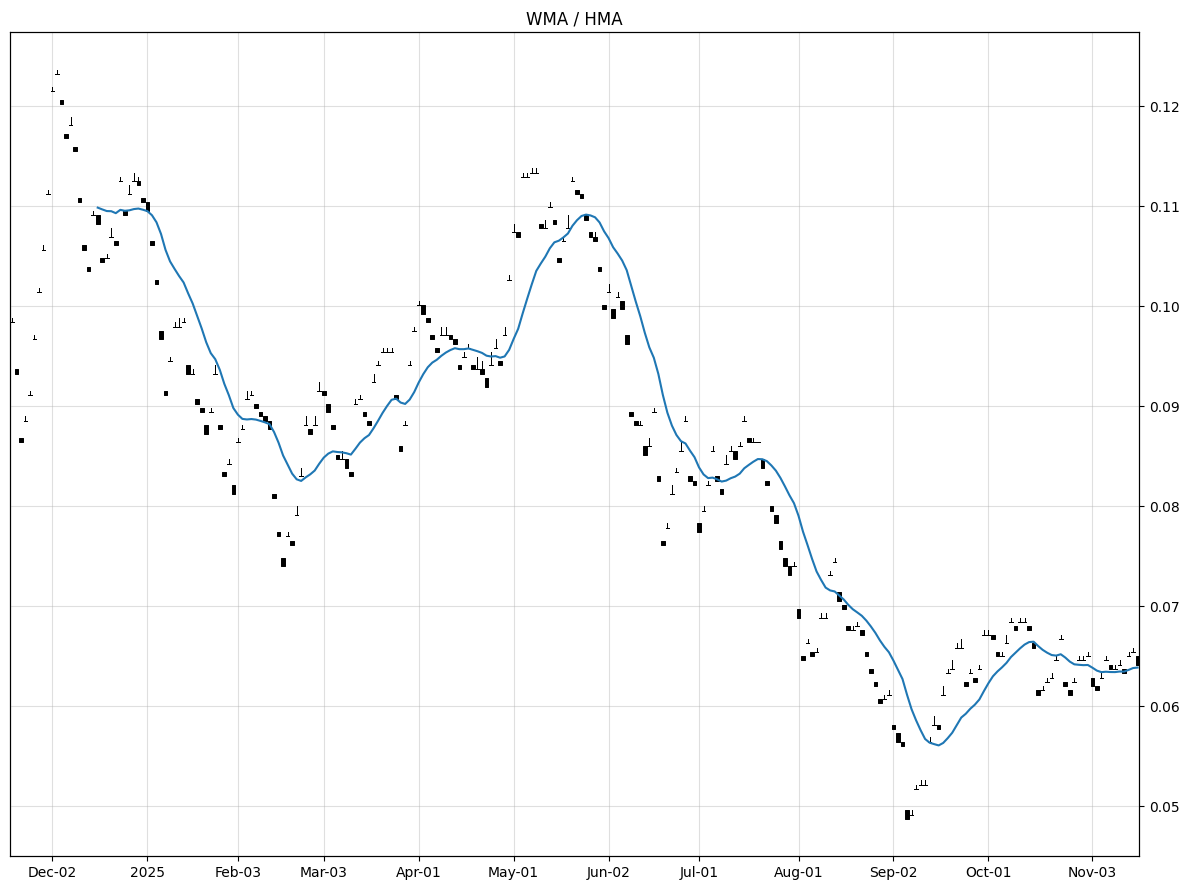

In [3]:
Chart(prices, title="WMA / HMA", max_bars=250).plot(
    Candlesticks(),
    WMA(20),
    HMA(20),
).show()

In [ ]:
Chart(prices, title="DEMA / TEMA", max_bars=250).plot(
    Candlesticks(),
    DEMA(20),
    TEMA(20),
).show()

## RSI

Relative Strength Index. Accepts an optional `src` expression.

In [ ]:
Chart(prices, title="RSI", max_bars=250).plot(
    Candlesticks(), SMA(50), Volume(),
).pane("above").plot(
    RSI(14),
).show()

## MACD

Moving Average Convergence Divergence — returns `(macd, signal, hist)`.

In [ ]:
Chart(prices, title="MACD", max_bars=250).plot(
    Candlesticks(), SMA(50), Volume(),
).pane("below").plot(
    MACD(12, 26, 9),
).show()

## Stochastic Oscillator

`STOCH` returns `(slowk, slowd)`.

In [ ]:
Chart(prices, title="Stochastic", max_bars=250).plot(
    Candlesticks(), SMA(50), Volume(),
).pane("below").plot(
    STOCH(),
).show()

## Rate of Change / Momentum

In [ ]:
Chart(prices, title="ROC", max_bars=250).plot(
    Candlesticks(), Volume(),
).pane("below").plot(
    ROC(14),
).show()

## Bollinger Bands

`BBANDS` returns `(upperband, middleband, lowerband)`.

In [ ]:
Chart(prices, title="Bollinger Bands", max_bars=250).plot(
    Candlesticks(), Volume(), BBANDS(),
).show()

## Donchian Channel

Highest high / lowest low over a lookback period — returns `(upperband, middleband, lowerband)`.

In [ ]:
Chart(prices, title="Donchian Channel", max_bars=250).plot(
    Candlesticks(), DONCHIAN(),
).show()

## Keltner Channel

EMA-based channel using ATR for band width — returns `(upperband, middleband, lowerband)`.

In [ ]:
Chart(prices, title="Keltner Channel", max_bars=250).plot(
    Candlesticks(), KELTNER(),
).show()

## ATR / True Range

In [ ]:
Chart(prices, title="ATR", max_bars=250).plot(
    Candlesticks(), Volume(),
).pane("below").plot(
    ATR(14),
).show()

## Price Series

`MIDPRICE` (HL/2), `TYPPRICE` (HLC/3), `WCLPRICE` (weighted close HLCC/4).

In [ ]:
Chart(prices, title="Price Series", max_bars=250).plot(
    Candlesticks(),
    MIDPRICE(),
    TYPPRICE(),
    WCLPRICE(),
).show()

## Composing Expressions

Expressions can be composed by passing one as the `src` argument of another.

In [ ]:
# RSI of EMA instead of close
Chart(prices, title="RSI of EMA(10)", max_bars=250).plot(
    Candlesticks(), Volume(),
).pane("above").plot(
    RSI(14, src=EMA(10)),
).show()

In [ ]:
# MACD on typical price
Chart(prices, title="MACD of TypPrice", max_bars=250).plot(
    Candlesticks(), Volume(),
).pane("below").plot(
    MACD(12, 26, 9, src=TYPPRICE()),
).show()